## ETL

In [3]:
# Celda 1: Configuración general

from pathlib import Path
import sys
import os
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Detectar la raíz del proyecto.
# Funciona si el notebook se abre desde notebooks/ o desde la raíz.
RUTA_ACTUAL = Path.cwd()
PROJECT_ROOT = RUTA_ACTUAL.parent if RUTA_ACTUAL.name == "notebooks" else RUTA_ACTUAL

os.chdir(PROJECT_ROOT)

SRC_PATH = str(PROJECT_ROOT / "src")
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

from extract import descargar_dataset, extraer_datos
from transform import (
    preparar_metadata,
    crear_muestra_balanceada,
    obtener_una_imagen_por_forma,
    procesar_multiples_resoluciones,
    guardar_metadata_muestra
)

print(f"Raíz del proyecto: {PROJECT_ROOT}")


Raíz del proyecto: c:\Users\jrabbat\Documents\Computación_paralela_distribuida\Proyecto_diamantes_CPD


In [ ]:
# Celda 2: Parámetros de ejecución

# True: procesa una muestra pequeña para pruebas.
# False: procesa todo el dataset.
MODO_PRUEBA = False

# Cambiar a True solamente si el dataset todavía no existe en data/raw.
DESCARGAR_DATASET = False

# Parámetros de prueba
MUESTRAS_POR_FORMA = 5
LIMITE_MUESTRA = 100
NUM_PROCESOS_PRUEBA = 2
TAMANO_LOTE_PRUEBA = 50

# Parámetros para el dataset completo
NUM_PROCESOS_COMPLETO = 8
TAMANO_LOTE_COMPLETO = 2000

# Resoluciones requeridas
RESOLUCIONES = [
    (224, 224),
    (256, 256)
]

CARPETA_SALIDA_PRUEBA = "data/processed_sample"
CARPETA_SALIDA_COMPLETA = "data/processed"

print("Modo seleccionado:", "PRUEBA" if MODO_PRUEBA else "DATASET COMPLETO")


Modo seleccionado: PRUEBA


In [5]:
# Celda 3: Descargar el dataset de Kaggle (opcional)

if DESCARGAR_DATASET:
    print("Descargando dataset...")
    descargar_dataset(
        ruta_destino="data/raw"
    )
else:
    print("Descarga omitida. Se utilizará el dataset existente en data/raw.")


Descarga omitida. Se utilizará el dataset existente en data/raw.


In [6]:
# Celda 4: Extraer rutas, etiquetas y metadatos

rutas, labels, metadata = extraer_datos(
    carpeta_padre="data/raw"
)

print(f"Total de imágenes encontradas: {len(rutas)}")
print(f"Total de etiquetas: {len(labels)}")
print(f"Total de registros en el CSV: {len(metadata)}")

display(metadata.head())



Iniciando etapa de extracción...
Se encontraron 48765 imágenes.
Metadata cargada correctamente: 48765 registros.
Columnas encontradas: ['path_to_img', 'stock_number', 'shape', 'carat', 'clarity', 'colour', 'cut', 'polish', 'symmetry', 'fluorescence', 'lab', 'length', 'width', 'depth']
Etapa de extracción finalizada correctamente.

Total de imágenes encontradas: 48765
Total de etiquetas: 48765
Total de registros en el CSV: 48765


,path_to_img,stock_number,shape,carat,clarity,colour,cut,polish,symmetry,fluorescence,lab,length,width,depth
0,web_scraped/cushion/2106452.jpg,2106452,cushion,0.55,SI2,N,VG,EX,VG,N,GIA,4.56,4.44,3.09
1,web_scraped/cushion/2042329.jpg,2042329,cushion,0.52,SI2,Y-Z,EX,EX,VG,F,GIA,4.40,4.31,2.99
2,web_scraped/cushion/2055268.jpg,2055268,cushion,0.50,SI1,L,VG,EX,VG,N,GIA,4.87,4.19,2.89
3,web_scraped/cushion/2128779.jpg,2128779,cushion,0.50,VS2,M,EX,EX,VG,F,GIA,4.73,4.28,2.84
4,web_scraped/cushion/2103991.jpg,2103991,cushion,0.51,SI1,M,EX,EX,VG,N,GIA,4.47,4.44,3.05


In [7]:
# Celda 5: Analizar la distribución original

print("Distribución original por forma:")
display(
    metadata["shape"]
    .value_counts(dropna=False)
    .rename_axis("shape")
    .reset_index(name="cantidad")
)

print("Distribución original por color:")
display(
    metadata["colour"]
    .value_counts(dropna=False)
    .rename_axis("colour")
    .reset_index(name="cantidad")
)

print("Distribución original por claridad:")
display(
    metadata["clarity"]
    .value_counts(dropna=False)
    .rename_axis("clarity")
    .reset_index(name="cantidad")
)


Distribución original por forma:


,shape,cantidad
0,round,21032
1,oval,6492
2,cushion,5341
3,pear,4338
4,princess,3949
5,heart,3756
6,emerald,3392
7,marquise,465


Distribución original por color:


,colour,cantidad
0,G,7674
1,F,6957
2,H,6555
3,E,6239
4,D,5824
5,I,5304
6,J,4273
7,K,2628
8,L,1388
9,M,754


Distribución original por claridad:


,clarity,cantidad
0,VS2,10688
1,SI1,10244
2,SI2,10019
3,VS1,9080
4,VVS2,4716
5,VVS1,2753
6,IF,854
7,I1,280
8,NaN,38
9,I2,35


In [8]:
# Celda 6: Preparar y validar los metadatos

datos_validos = preparar_metadata(
    metadata=metadata,
    carpeta_datos="data/raw"
)

print(f"Registros válidos para procesar: {len(datos_validos)}")

display(
    datos_validos[
        [
            "path_to_img",
            "shape",
            "colour",
            "colour_group",
            "clarity",
            "full_path"
        ]
    ].head()
)


Registros iniciales: 48765
Registros válidos: 48411
Registros descartados: 354
Registros válidos para procesar: 48411


,path_to_img,shape,colour,colour_group,clarity,full_path
0,web_scraped/cushion/2106452.jpg,cushion,N,N-R,SI2,data\raw\web_scraped\cushion\2106452.jpg
1,web_scraped/cushion/2042329.jpg,cushion,Y-Z,S-Z,SI2,data\raw\web_scraped\cushion\2042329.jpg
2,web_scraped/cushion/2055268.jpg,cushion,L,K-M,SI1,data\raw\web_scraped\cushion\2055268.jpg
3,web_scraped/cushion/2128779.jpg,cushion,M,K-M,VS2,data\raw\web_scraped\cushion\2128779.jpg
4,web_scraped/cushion/2103991.jpg,cushion,M,K-M,SI1,data\raw\web_scraped\cushion\2103991.jpg


In [9]:
# Celda 7: Seleccionar muestra o dataset completo

if MODO_PRUEBA:
    datos_a_procesar = crear_muestra_balanceada(
        metadata=datos_validos,
        muestras_por_forma=MUESTRAS_POR_FORMA,
        limite_total=LIMITE_MUESTRA,
        semilla=42
    )

    carpeta_salida = CARPETA_SALIDA_PRUEBA
    num_procesos = NUM_PROCESOS_PRUEBA
    tamano_lote = TAMANO_LOTE_PRUEBA

else:
    datos_a_procesar = datos_validos.copy()

    carpeta_salida = CARPETA_SALIDA_COMPLETA
    num_procesos = NUM_PROCESOS_COMPLETO
    tamano_lote = TAMANO_LOTE_COMPLETO

print(f"Imágenes a procesar: {len(datos_a_procesar)}")
print(f"Carpeta de salida: {carpeta_salida}")
print(f"Número de procesos: {num_procesos}")
print(f"Tamaño de lote: {tamano_lote}")



Muestra balanceada creada.
Cantidad total: 40

Distribución por forma:
shape
cushion     5
emerald     5
heart       5
marquise    5
oval        5
pear        5
princess    5
round       5
Name: count, dtype: int64

Distribución por grupo de color:
colour_group
D      5
E-F    6
G-H    9
I-J    8
K-M    5
N-R    3
S-Z    4
Name: count, dtype: int64

Distribución por claridad:
clarity
I1      6
IF      3
SI1     8
SI2     5
VS1     5
VS2     7
VVS1    5
VVS2    1
Name: count, dtype: int64

Valores faltantes:
shape           0
colour          0
colour_group    0
clarity         0
dtype: int64
Imágenes a procesar: 40
Carpeta de salida: data/processed_sample
Número de procesos: 2
Tamaño de lote: 50


In [10]:
# Celda 8: Revisar distribuciones de los datos seleccionados

print("Distribución por forma:")
display(
    datos_a_procesar["shape"]
    .value_counts()
    .sort_index()
)

print("Distribución por grupo de color:")
display(
    datos_a_procesar["colour_group"]
    .value_counts()
    .sort_index()
)

print("Distribución por claridad:")
display(
    datos_a_procesar["clarity"]
    .value_counts()
    .sort_index()
)

print("Valores faltantes:")
display(
    datos_a_procesar[
        ["shape", "colour", "colour_group", "clarity"]
    ].isna().sum()
)


Distribución por forma:


shape
cushion     5
emerald     5
heart       5
marquise    5
oval        5
pear        5
princess    5
round       5
Name: count, dtype: int64

Distribución por grupo de color:


colour_group
D      5
E-F    6
G-H    9
I-J    8
K-M    5
N-R    3
S-Z    4
Name: count, dtype: int64

Distribución por claridad:


clarity
I1      6
IF      3
SI1     8
SI2     5
VS1     5
VS2     7
VVS1    5
VVS2    1
Name: count, dtype: int64

Valores faltantes:


shape           0
colour          0
colour_group    0
clarity         0
dtype: int64

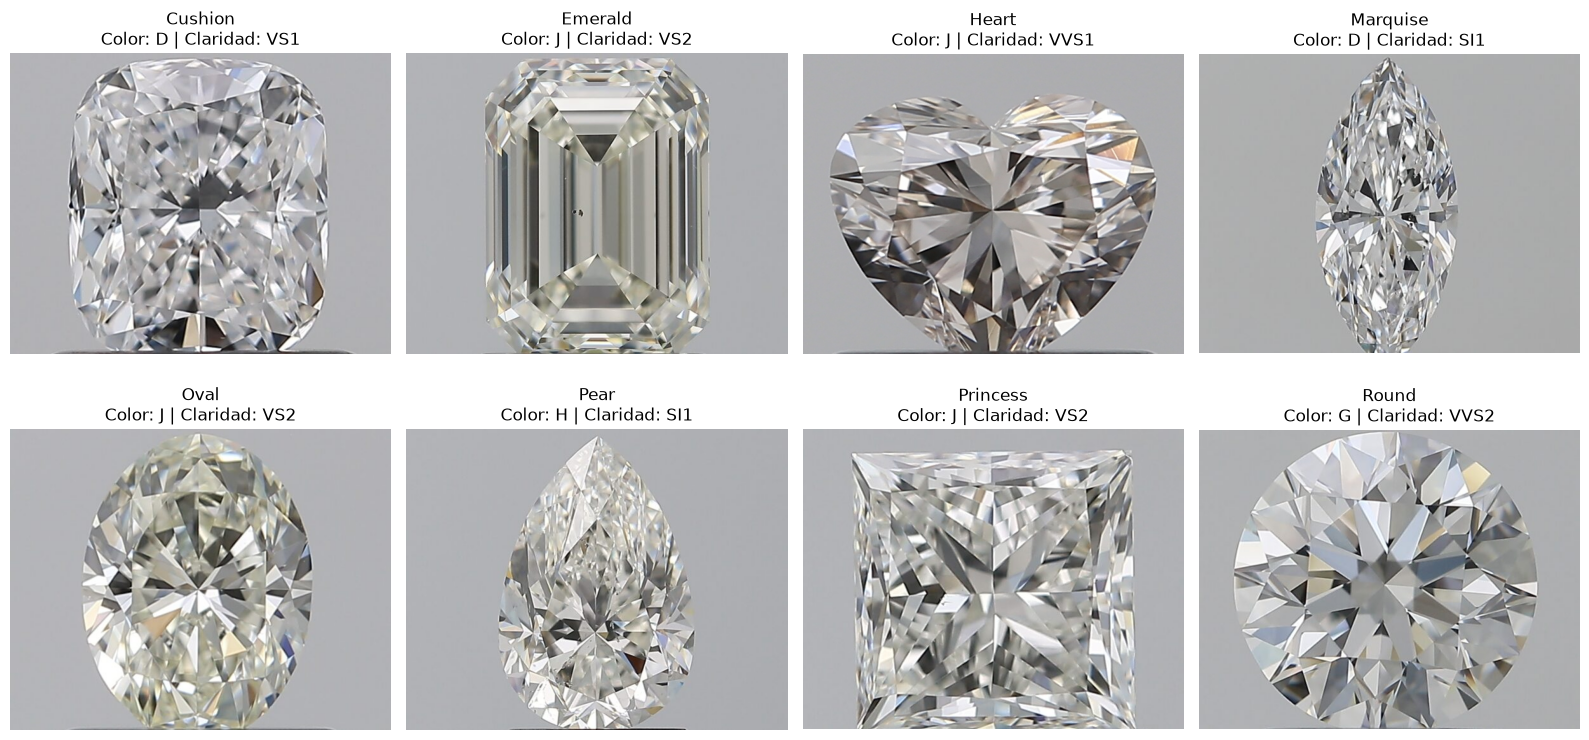

In [11]:
# Celda 9: Visualizar una imagen por cada forma

muestra_visual = obtener_una_imagen_por_forma(
    metadata=datos_validos,
    semilla=42
)

cantidad = len(muestra_visual)
columnas = 4
filas = int(np.ceil(cantidad / columnas))

plt.figure(figsize=(16, filas * 4))

for posicion, (_, registro) in enumerate(
    muestra_visual.iterrows(),
    start=1
):
    imagen = cv2.imread(registro["full_path"])

    plt.subplot(filas, columnas, posicion)

    if imagen is not None:
        imagen = cv2.cvtColor(
            imagen,
            cv2.COLOR_BGR2RGB
        )
        plt.imshow(imagen)

    plt.title(
        f"{registro['shape'].title()}\n"
        f"Color: {registro['colour']} | "
        f"Claridad: {registro['clarity']}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


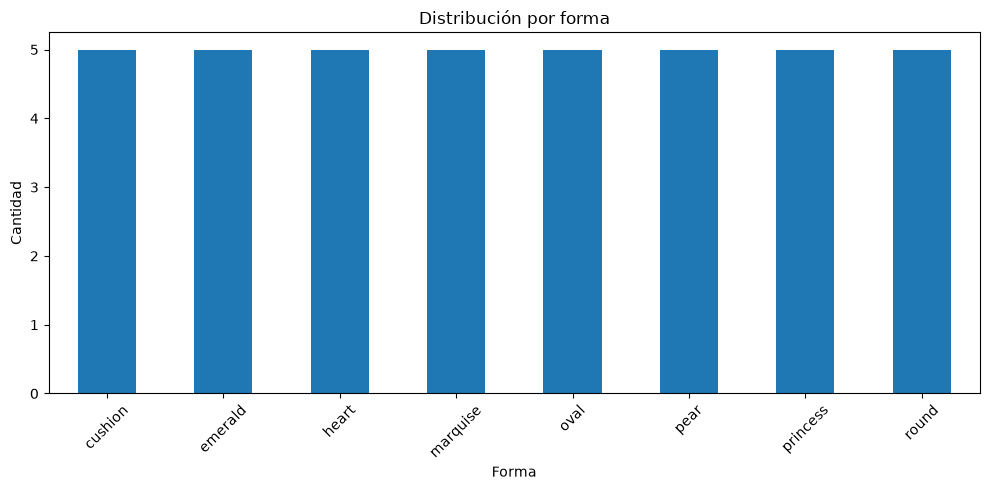

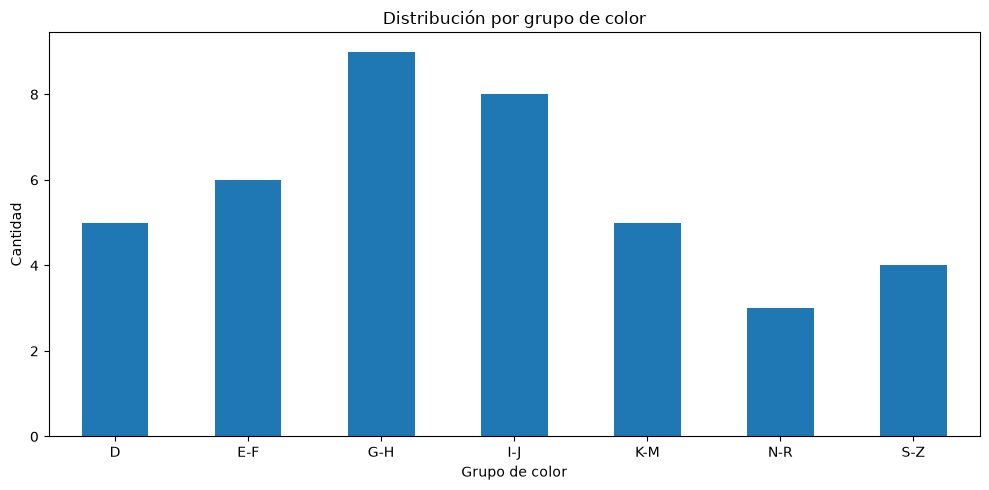

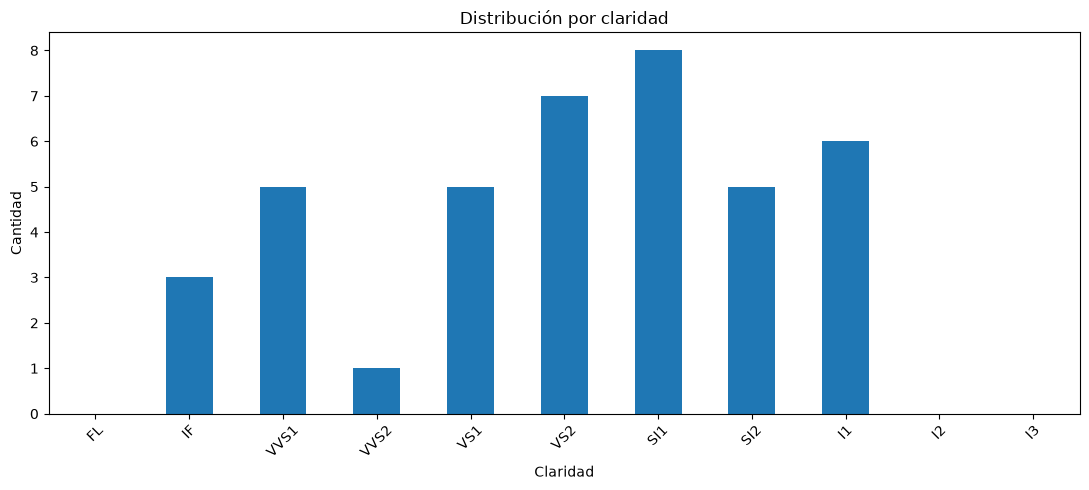

In [12]:
# Celda 10: Gráficos de distribución

orden_colores = [
    "D",
    "E-F",
    "G-H",
    "I-J",
    "K-M",
    "N-R",
    "S-Z"
]

orden_claridad = [
    "FL",
    "IF",
    "VVS1",
    "VVS2",
    "VS1",
    "VS2",
    "SI1",
    "SI2",
    "I1",
    "I2",
    "I3"
]

conteo_formas = (
    datos_a_procesar["shape"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))
conteo_formas.plot(kind="bar")
plt.title("Distribución por forma")
plt.xlabel("Forma")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

conteo_colores = (
    datos_a_procesar["colour_group"]
    .value_counts()
    .reindex(orden_colores, fill_value=0)
)

plt.figure(figsize=(10, 5))
conteo_colores.plot(kind="bar")
plt.title("Distribución por grupo de color")
plt.xlabel("Grupo de color")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

conteo_claridad = (
    datos_a_procesar["clarity"]
    .value_counts()
    .reindex(orden_claridad, fill_value=0)
)

plt.figure(figsize=(11, 5))
conteo_claridad.plot(kind="bar")
plt.title("Distribución por claridad")
plt.xlabel("Claridad")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Celda 11: Guardar los metadatos de las imágenes seleccionadas

ruta_metadata_salida = os.path.join(
    carpeta_salida,
    "metadata_procesada.csv"
)

guardar_metadata_muestra(
    metadata=datos_a_procesar,
    ruta_salida=ruta_metadata_salida
)


In [ ]:
# Celda 12: Procesar las imágenes en 224 × 224 y 256 × 256

rutas_a_procesar = datos_a_procesar["full_path"].tolist()

inicio = time.time()

resultados = procesar_multiples_resoluciones(
    rutas_imagenes=rutas_a_procesar,
    resoluciones=RESOLUCIONES,
    num_procesos=num_procesos,
    tamaño_lote=tamano_lote,
    carpeta_salida=carpeta_salida
)

tiempo_total = time.time() - inicio

print("\nProcesamiento finalizado.")
print(f"Total de imágenes: {len(rutas_a_procesar)}")
print(f"Tiempo total: {tiempo_total / 60:.2f} minutos")


In [ ]:
# Celda 13: Validar los lotes sin cargar todo el dataset en memoria

def validar_lotes(carpeta_resolucion, tamano_esperado):
    archivos = sorted(
        Path(carpeta_resolucion).glob("lote_*.npz")
    )

    if not archivos:
        raise FileNotFoundError(
            f"No se encontraron lotes en {carpeta_resolucion}"
        )

    total_imagenes = 0
    total_rutas = 0

    for archivo in archivos:
        with np.load(archivo) as lote:
            imagenes = lote["images"]
            rutas_lote = lote["paths"]

            assert imagenes.ndim == 4, (
                f"Dimensiones inválidas en {archivo}"
            )

            assert imagenes.shape[1:] == (
                tamano_esperado[1],
                tamano_esperado[0],
                3
            ), (
                f"Resolución incorrecta en {archivo}: "
                f"{imagenes.shape}"
            )

            assert len(imagenes) == len(rutas_lote), (
                f"No coinciden imágenes y rutas en {archivo}"
            )

            total_imagenes += len(imagenes)
            total_rutas += len(rutas_lote)

    print(f"Carpeta validada: {carpeta_resolucion}")
    print(f"Lotes encontrados: {len(archivos)}")
    print(f"Imágenes procesadas: {total_imagenes}")
    print(f"Rutas registradas: {total_rutas}")

    return total_imagenes


total_224 = validar_lotes(
    carpeta_resolucion=os.path.join(
        carpeta_salida,
        "224x224"
    ),
    tamano_esperado=(224, 224)
)

total_256 = validar_lotes(
    carpeta_resolucion=os.path.join(
        carpeta_salida,
        "256x256"
    ),
    tamano_esperado=(256, 256)
)

assert total_224 == len(datos_a_procesar), (
    "La cantidad procesada en 224 × 224 no coincide."
)

assert total_256 == len(datos_a_procesar), (
    "La cantidad procesada en 256 × 256 no coincide."
)

print("\nTodas las imágenes fueron procesadas correctamente.")
